# **Recurrent Deep Sets Demo**
#### **By Luke O'Leary**
#### **August 5th, 2026**

In [5]:
# Load libraries
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
import keras
from keras import models
from keras import layers
import random
from pathlib import Path

# Plot formatting
fpath = Path(mpl.get_data_path(), "fonts/ttf/cmr10.ttf")


# **Data Preprocessing**

## Motor Gasoline Product Supplied (Output Data)

(Source: [US Energy Information Administration](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=WGFUPUS2&f=W))

In [77]:
# Read in weekly gasoline product supplied data 
gas_df = pd.read_csv("weekly_gas.csv")
gas_df["date"] = pd.to_datetime(gas_df["date"])

# Split into train / validation / test sets
gas_df_train = gas_df[gas_df["date"] <= pd.to_datetime("01/01/2021")]
gas_df_val = gas_df[(gas_df["date"] > pd.to_datetime("01/01/2021")) & (gas_df["date"] <= pd.to_datetime("10/01/2021"))]
gas_df_test = gas_df[(gas_df["date"] > pd.to_datetime("10/01/2021"))]

# Standardize according to training set mean and standard deviation (avoiding data leakage)
train_mean_gas = gas_df_train["weekly_gas"].mean()
train_std_gas = gas_df_train["weekly_gas"].std()

gas_train_prep = (gas_df_train["weekly_gas"] - train_mean_gas) / train_std_gas
gas_val_prep = (gas_df_val["weekly_gas"] - train_mean_gas) / train_std_gas
gas_test_prep = (gas_df_test["weekly_gas"] - train_mean_gas) / train_std_gas

/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/1808682857.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gas_df["date"] = pd.to_datetime(gas_df["date"])


In [ ]:
# Plot 1a - Weekly Gasoline Product Supplied
plt.clf()
plt.figure(figsize=(16,6))
plt.plot(gas_df["date"], gas_df["weekly_gas"], 'b',color="brown")
plt.title('Weekly US Product Supplied of Finished Motor Gasoline (thousand barrels per day)', font=fpath, fontsize=18)
plt.yticks(font=fpath, fontsize=12)
plt.xticks(font=fpath, fontsize=12)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.savefig("weekly_gas.png", dpi=600, bbox_inches="tight")
plt.show()

## Traffic Congestion Events (Input Data)

(Source: [US Traffic Congestions (2016-2022)](https://www.kaggle.com/datasets/sobhanmoosavi/us-traffic-congestions-2016-2022))

In [ ]:
# Download and read in latest version of traffic/weather dataset
path = kagglehub.dataset_download("sobhanmoosavi/us-traffic-congestions-2016-2022")
print("Path to dataset files:", path)
traffic_df = pd.read_csv(path)

In [83]:
# Remove excess columns
traffic_df = traffic_df[["Start_Lat", "Start_Lng","StartTime","EndTime","Distance(mi)","DelayFromTypicalTraffic(mins)","DelayFromFreeFlowSpeed(mins)","Congestion_Speed","Severity",
                         "Temperature(F)","WindChill(F)","Humidity(%)","Pressure(in)","Visibility(mi)","WindSpeed(mph)","Precipitation(in)","Weather_Event"]]

# Convert StartTime and EndTime to datetime objects
traffic_df["StartTime"] = pd.to_datetime(traffic_df["StartTime"], utc=True) # Coerce time zones to UTC
traffic_df["EndTime"] = pd.to_datetime(traffic_df["EndTime"], utc=True) # Coerce time zones to UTC
traffic_df = traffic_df[~traffic_df["StartTime"].isna()] # Remove rows with missing StartTime (missing after 2022-09-08)

# Split data into training, validation, and test
# Clip time windows to align with gasoline product supplied reporting schedule 
traffic_df_train = traffic_df[(traffic_df["StartTime"] >= pd.to_datetime("02/12/2016 12:00", utc=True)) & (traffic_df["StartTime"] < pd.to_datetime("01/01/2021 12:00", utc=True))]  # Sep 2016 - Dec 2020
traffic_df_val = traffic_df[(traffic_df["StartTime"] >= pd.to_datetime("01/01/2021 12:00", utc=True)) & (traffic_df["StartTime"] < pd.to_datetime("10/01/2021 12:00", utc=True))] #  Jan 2021 - Sep 2021
traffic_df_test = traffic_df[(traffic_df["StartTime"] >= pd.to_datetime("10/01/2021 12:00", utc=True)) & (traffic_df["StartTime"] < pd.to_datetime("09/02/2022 12:00", utc=True))] # Oct 2021 - Sep 2022


In [84]:
# Function for building sets table - establishes time windows for all hours in the dataset, including those with no traffic events
# (start_datetime and end_datetime are string inputs)

def build_sets(start_date, end_date):
    
    # Date
    sets = pd.DataFrame(pd.date_range(start=pd.to_datetime(start_date, utc=True), end=pd.to_datetime(end_date, utc=True), freq="d", name="date"))
    sets["date"] = sets["date"].dt.date 
    sets = sets.loc[sets.index.repeat(24)].reset_index(drop=True)

    # Hour
    sets["hour"] = np.tile(np.append(np.arange(12,24),np.arange(0,12)),int(sets.shape[0]/24))

    # Drop rows outside window
    sets = sets[~((sets["date"] == sets["date"][0]) & (sets["hour"] < 12))]
    sets = sets[~((sets["date"] == sets["date"][sets.shape[0]]) & (sets["hour"] >= 12))]
    sets = sets.sort_values(["date","hour"]).reset_index(drop=True)

    # Row (one time series = one week)
    sets["row"] = np.arange(0,int(sets.shape[0]/(24*7))).repeat(24*7)

    # Set (unique hour window)
    sets["set"] = sets.index # Set number

    return(sets)


In [ ]:
# Function which performs similar preprocessing across train, val, and test datasets
def preprocess(df, start_date, end_date, drop_hour=True):

    traffic_prep_df = df

    # Duration of traffic congestion event
    traffic_prep_df["Duration"] = abs(traffic_prep_df["EndTime"] - traffic_prep_df["StartTime"]) # Switch sign when StartTime mis-recorded as Endtime and vice-versa 
    traffic_prep_df["Duration_hours"] = traffic_prep_df["Duration"] / pd.Timedelta(1, 'hour') # Convert to hours

    # Build sets based on StartTime
    traffic_prep_df["date"] = traffic_prep_df["StartTime"].dt.date
    traffic_prep_df["hour"] = traffic_prep_df["StartTime"].dt.hour
    traffic_prep_df = traffic_prep_df.sort_values(["date","hour"]) # Sort chronologically 
    traffic_prep_df = traffic_prep_df.reset_index(drop=True) # Reset index

    # Sets table - establishes time windows for all hours between first StartTime and last StartTime, including those with no traffic events
    sets = build_sets(start_date, end_date)

    traffic_prep_df = pd.merge(traffic_prep_df, sets, how="left", on=["date","hour"]) # Assign set based on hour window
    empty_sets = sets[["set","row","hour"]][~sets["set"].isin(traffic_prep_df["set"])] # Identify all time-windows with 0 traffic events

    # Map Congestion_Speed to numeric
    traffic_prep_df["Congestion_Speed"] = traffic_prep_df["Congestion_Speed"].map({"Fast": 0, "Moderate": 1, "Slow": 2})

    # Build Weather Event Binary Label columns from Weather_Event
    traffic_prep_df["Weather_Event"] = traffic_prep_df["Weather_Event"].apply(lambda x: str(x)) # Convert Weather_Event to string
    traffic_prep_df["Rain_Event"] = ~(traffic_prep_df["Weather_Event"].apply(lambda x: x.find('Rain')) == -1)
    traffic_prep_df["Snow_Event"] = ~(traffic_prep_df["Weather_Event"].apply(lambda x: x.find('Snow')) == -1)
    traffic_prep_df["Fog_Event"] = ~(traffic_prep_df["Weather_Event"].apply(lambda x: x.find('Fog')) == -1)
    traffic_prep_df["Thunderstorm_Event"] = ~(traffic_prep_df["Weather_Event"].apply(lambda x: x.find('Thunderstorm')) == -1)
    traffic_prep_df["Hail_Event"] = ~(traffic_prep_df["Weather_Event"].apply(lambda x: x.find('Hail')) == -1)
    traffic_prep_df["Tornado_Event"] = ~(traffic_prep_df["Weather_Event"].apply(lambda x: x.find('Tornado')) == -1)
    traffic_prep_df[["Rain_Event","Snow_Event","Fog_Event","Thunderstorm_Event","Hail_Event","Tornado_Event"]] = traffic_prep_df[["Rain_Event","Snow_Event","Fog_Event","Thunderstorm_Event","Hail_Event","Tornado_Event"]].map(lambda x: int(x)) # Convert to int

    # Drop excess columns 
    if drop_hour:
        traffic_prep_df = traffic_prep_df.drop(["StartTime","EndTime","Duration","Weather_Event","date","hour"], axis=1)

    else:
        # Include hour column for Plot 2
        traffic_prep_df = traffic_prep_df.drop(["StartTime","EndTime","Duration","Weather_Event","date"], axis=1)
    
    # Make row,set first columns
    set_col = traffic_prep_df.pop("set")
    traffic_prep_df.insert(0, "set", set_col)
    row_col = traffic_prep_df.pop("row")
    traffic_prep_df.insert(0, "row", row_col)

    # For empty sets, set one congestion event with all feature values set to zero or mean (depending on context)
    empty_event = pd.DataFrame(
        {"Start_Lat": [traffic_prep_df["Start_Lat"].mean()],
        "Start_Lng": [traffic_prep_df["Start_Lng"].mean()],
        "Distance(mi)": [0],
        "DelayFromTypicalTraffic(mins)": [0],
        "DelayFromFreeFlowSpeed(mins)": [0],
        "Congestion_Speed": [0],
        "Severity": [0],
        "Temperature(F)": [traffic_prep_df["Temperature(F)"].mean()],
        "WindChill(F)": [traffic_prep_df["WindChill(F)"].mean()],
        "Humidity(%)": [traffic_prep_df["Humidity(%)"].mean()],
        "Pressure(in)": [traffic_prep_df["Pressure(in)"].mean()],
        "Visibility(mi)": [traffic_prep_df["Visibility(mi)"].mean()],
        "WindSpeed(mph)": [traffic_prep_df["WindSpeed(mph)"].mean()],
        "Precipitation(in)": [traffic_prep_df["Precipitation(in)"].mean()],
        "Duration_hours": [0],
        "Rain_Event": [0],
        "Snow_Event": [0],
        "Fog_Event": [0],
        "Thunderstorm_Event": [0],
        "Hail_Event": [0],
        "Tornado_Event": [0]})

    # Create and append rows for each empty set
    empty_set_events = pd.DataFrame(np.repeat(empty_event, empty_sets.shape[0], axis=0), columns=empty_event.columns)
    empty_set_rows = pd.concat([empty_sets.reset_index(drop=True), empty_set_events], axis=1)
    traffic_prep_df = pd.concat([traffic_prep_df, empty_set_rows], axis=0)  # Row-bind empty set rows to traffic_prep_df
    
    # Sort by row, set
    traffic_prep_df = traffic_prep_df.sort_values(["row","set"])
    
    return(traffic_prep_df)

traffic_train_prep = preprocess(traffic_df_train, "02/12/2016", "01/01/2021")
traffic_val_prep = preprocess(traffic_df_val,"01/01/2021","10/01/2021")
traffic_test_prep = preprocess(traffic_df_test,"10/01/2021","09/02/2022")

In [ ]:
# Plot 2 - Average traffic events by hour across the US over one week

plot2_train = preprocess(traffic_df_train, "02/12/2016", "01/01/2021", drop_hour=False)
plot2_val= preprocess(traffic_df_val, "01/01/2021","10/01/2021", drop_hour=False)
plot2_test= preprocess(traffic_df_test, "10/01/2021","09/02/2022", drop_hour=False)

# Accumulate event counts based on which hour position in the week they took place
events_by_hour = np.zeros((168,))
for w in range(255):
    week_data = plot2_train[plot2_train["row"] == w]
    week_data = week_data.sort_values("set")
    week_data = week_data.groupby(["set","hour"]).size().reset_index(name="event_count")
    events_by_hour += week_data["event_count"]

for w in range(39):
    week_data = plot2_val[plot2_val["row"] == w]
    week_data = week_data.sort_values("set")
    week_data = week_data.groupby(["set","hour"]).size().reset_index(name="event_count")
    events_by_hour += week_data["event_count"]

for w in range(48):
    week_data = plot2_test[plot2_test["row"] == w]
    week_data = week_data.sort_values("set")
    week_data = week_data.groupby(["set","hour"]).size().reset_index(name="event_count")
    events_by_hour += week_data["event_count"]

events_by_hour = events_by_hour / (255+39+48) # Average week
events_by_hour = np.array(events_by_hour)
events_by_hour = np.concatenate((events_by_hour[5:], events_by_hour[:5]))

/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_14771/1658654232.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(plot2_df, 'b',color="black")


<Figure size 640x480 with 0 Axes>

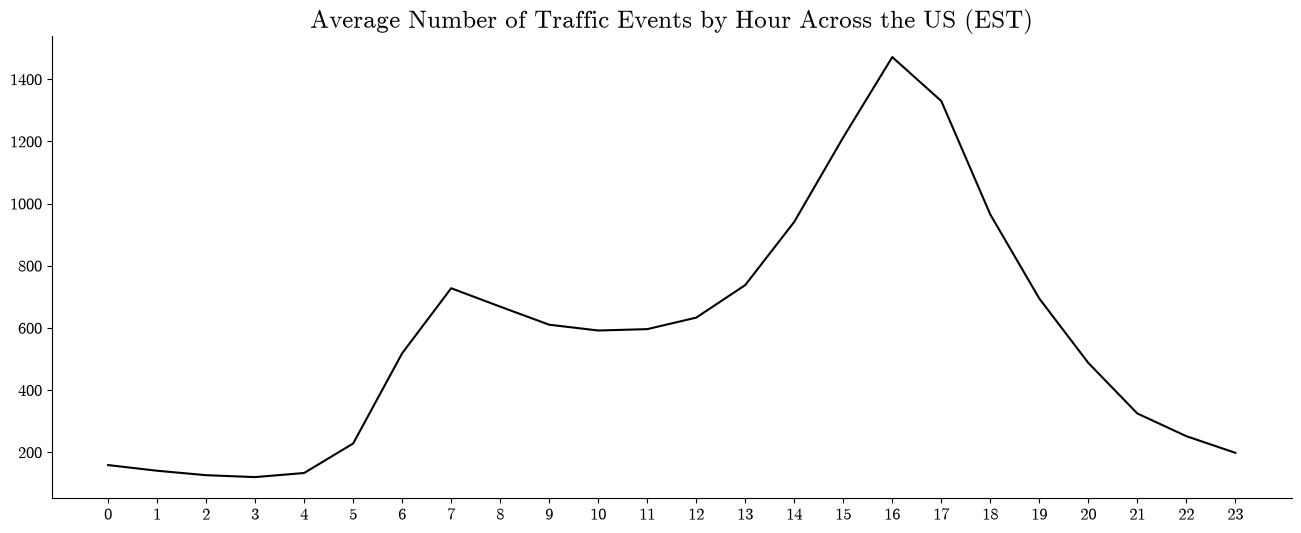

In [ ]:
plt.clf()
plt.figure(figsize=(16,6))
plt.plot(events_by_hour, 'b',color="black")
plt.title('Average Traffic Congesiton Events by Hour Across the US over One Week', font=fpath, fontsize=18)
plt.xlabel("Hours since Friday 7:00 AM EST", font=fpath, fontsize=12)
plt.xticks(font=fpath, fontsize=12)
plt.yticks(font=fpath, fontsize=12)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.savefig("weekly_gas.png", dpi=300, bbox_inches="tight")
plt.show()


In [8]:
# Shift weeks for validation and test set
traffic_val_prep["row"] += 255 # 255 weeks in training set
traffic_test_prep["row"] += 294 # 255 weeks in training set, 39 weeks in validation set

In [9]:
# Function which imputes missing values in the weather columns to the column mean
def mean_impute(df):

    # Impute missing weather values with the column mean
    df.loc[df["Temperature(F)"].isnull(),"Temperature(F)"] = df["Temperature(F)"].mean()
    df.loc[df["WindChill(F)"].isnull(),"WindChill(F)"] = df["WindChill(F)"].mean()
    df.loc[df["Humidity(%)"].isnull(),"Humidity(%)"] = df["Humidity(%)"].mean()
    df.loc[df["Pressure(in)"].isnull(),"Pressure(in)"] = df["Pressure(in)"].mean()
    df.loc[df["Visibility(mi)"].isnull(),"Visibility(mi)"] = df["Visibility(mi)"].mean()
    df.loc[df["WindSpeed(mph)"].isnull(),"WindSpeed(mph)"] = df["WindSpeed(mph)"].mean()
    df.loc[df["Precipitation(in)"].isnull(),"Precipitation(in)"] = df["Precipitation(in)"].mean()

    return(df)

traffic_train_prep = mean_impute(traffic_train_prep)
traffic_val_prep = mean_impute(traffic_val_prep)
traffic_test_prep = mean_impute(traffic_test_prep)

In [84]:
traffic_train_prep.isnull().sum()

row                              0
set                              0
Start_Lat                        0
Start_Lng                        0
Distance(mi)                     0
DelayFromTypicalTraffic(mins)    0
DelayFromFreeFlowSpeed(mins)     0
Congestion_Speed                 0
Severity                         0
Temperature(F)                   0
WindChill(F)                     0
Humidity(%)                      0
Pressure(in)                     0
Visibility(mi)                   0
WindSpeed(mph)                   0
Precipitation(in)                0
Duration_hours                   0
Rain_Event                       0
Snow_Event                       0
Fog_Event                        0
Thunderstorm_Event               0
Hail_Event                       0
Tornado_Event                    0
dtype: int64

In [85]:
# Inspect for outliers in the dataset and potential clerical errors
traffic_train_prep.describe().apply(lambda x: x.apply('{0:.5f}'.format))

,row,set,Start_Lat,Start_Lng,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,Severity,Temperature(F),...,Visibility(mi),WindSpeed(mph),Precipitation(in),Duration_hours,Rain_Event,Snow_Event,Fog_Event,Thunderstorm_Event,Hail_Event,Tornado_Event
count,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,...,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000
mean,140.36181,23668.71672,37.19311,-92.51213,2.70382,2.74164,3.89061,0.91931,1.11222,60.95619,...,9.09166,8.95059,0.02734,0.84081,0.03778,0.04262,0.01241,0.00827,0.00001,0.00001
std,62.24724,10456.21580,5.21530,17.18236,2.60134,3.99177,4.48452,0.77756,0.76410,19.77890,...,803.33859,5.14430,0.26585,13.09366,0.19067,0.20200,0.11070,0.09058,0.00325,0.00260
min,0.00000,0.00000,24.54662,-124.55238,0.00000,0.00000,0.00000,0.00000,0.00000,-146.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,94.00000,15920.00000,33.77471,-107.21312,1.03000,0.37000,1.52000,0.00000,1.00000,48.00000,...,10.00000,5.80000,0.00000,0.69917,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
50%,138.00000,23313.00000,38.51890,-86.78625,2.09000,1.65000,2.80000,1.00000,1.00000,64.00000,...,10.00000,8.95059,0.02734,0.74250,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
75%,186.00000,31255.00000,40.87262,-77.55246,3.53000,3.75000,5.00000,2.00000,2.00000,75.90000,...,10.00000,11.50000,0.02734,0.90861,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
max,254.00000,42839.00000,49.00249,-67.01227,136.73000,327.60001,393.14999,2.00000,4.00000,192.00000,...,2800610.00000,1099.00000,25.00000,14208.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000


{'whiskers': [<matplotlib.lines.Line2D at 0x375eba7b0>,
 'caps': [<matplotlib.lines.Line2D at 0x375ebaa50>,
 'boxes': [<matplotlib.lines.Line2D at 0x375eba660>,
 'medians': [<matplotlib.lines.Line2D at 0x375ebacf0>,
 'fliers': [<matplotlib.lines.Line2D at 0x375ebae40>,
 'means': []}

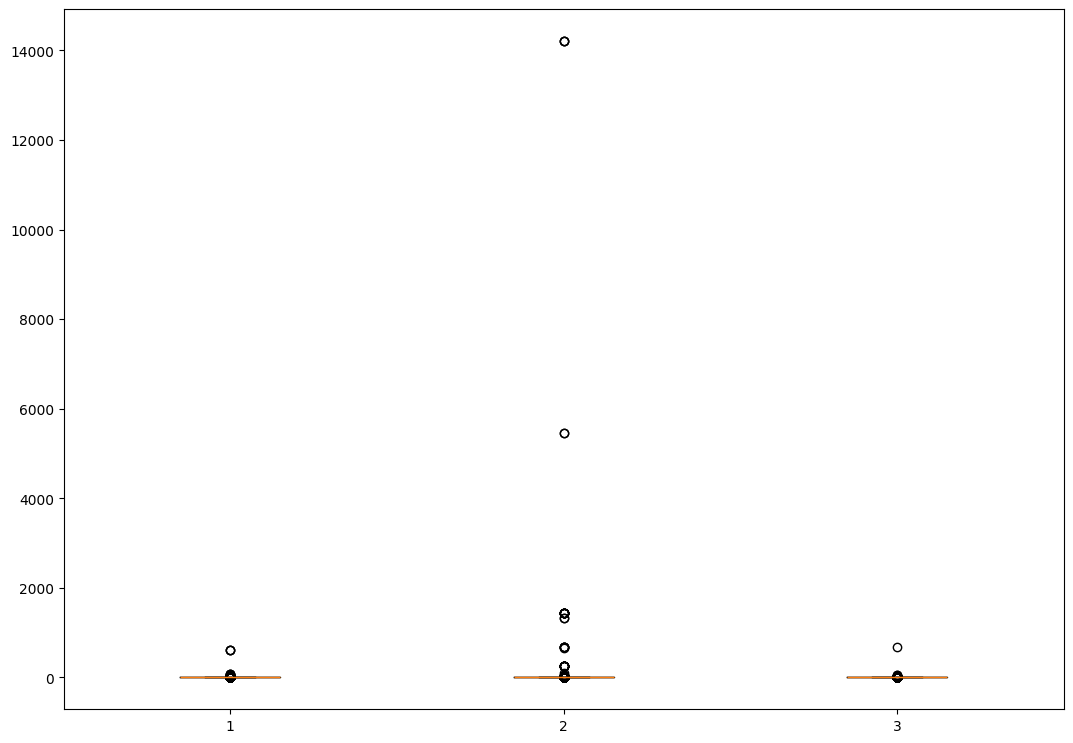

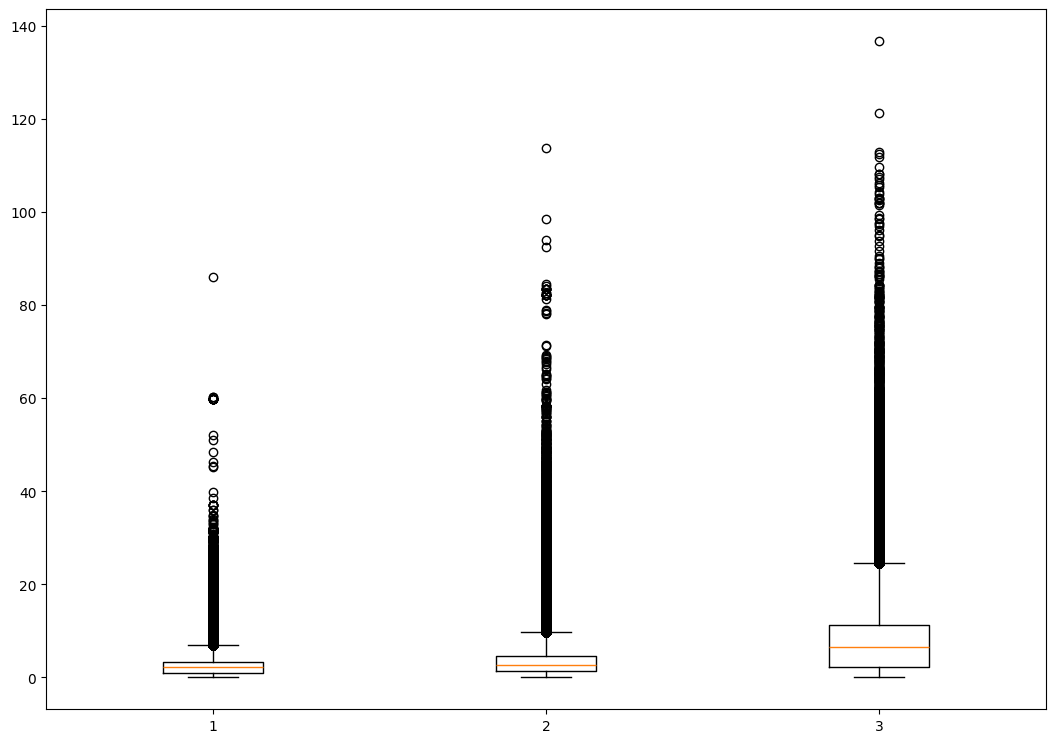

In [ ]:
# Duration by Severity Plot
severity_1_d = traffic_train_prep.loc[traffic_train_prep["Severity"] == 1, "Duration_hours"]
severity_2_d = traffic_train_prep.loc[traffic_train_prep["Severity"] == 2, "Duration_hours"]
severity_3_d = traffic_train_prep.loc[traffic_train_prep["Severity"] == 3, "Duration_hours"]
d = [severity_1_d,severity_2_d,severity_3_d]

fig = plt.figure(figsize=(10,7))
ax = fig.add_axes([0,0,1,1])
ax.boxplot(d)

# Distance by Severity Plot
severity_1_dis = traffic_train_prep.loc[traffic_train_prep["Severity"] == 1, "Distance(mi)"]
severity_2_dis = traffic_train_prep.loc[traffic_train_prep["Severity"] == 2, "Distance(mi)"]
severity_3_dis = traffic_train_prep.loc[traffic_train_prep["Severity"] == 3, "Distance(mi)"]
dis = [severity_1_dis,severity_2_dis,severity_3_dis]

fig = plt.figure(figsize=(10,7))
ax = fig.add_axes([0,0,1,1])
ax.boxplot(dis)

In [10]:
# Function which constrains traffic and weather variables to reasonable ranges
def clip_outliers(df):

    ## Traffic variables

    # Distance - clip observations to have maximum 20 miles of road affected
    df.loc[df["Distance(mi)"] > 20, "Distance(mi)"] = 20

    # Duration_hours, DelayFromTypicalTraffic(mins), DelayFromFreeFlowSpeed(mins) - clip observations to have maximum 1 hour 
    df.loc[df["Duration_hours"] > 1, "Duration_hours"] = 1
    df.loc[df["DelayFromTypicalTraffic(mins)"] > 60, "DelayFromTypicalTraffic(mins)"] = 60
    df.loc[df["DelayFromFreeFlowSpeed(mins)"] > 60, "DelayFromFreeFlowSpeed(mins)"] = 60

    ## Weather variables

    # Precipitation - clip observations to have maximum 25 inches of rain (i.e. hurricane)
    df.loc[df["Precipitation(in)"] > 25, "Precipitation(in)"] = 25

    # Temperature/WindChill - clip observations to have maximum 105 degrees and minimum -5 degrees
    df.loc[df["Temperature(F)"] > 105, "Temperature(F)"] = 105
    df.loc[df["Temperature(F)"] < -5, "Temperature(F)"] = -5
    df.loc[df["WindChill(F)"] > 105, "WindChill(F)"] = 105
    df.loc[df["WindChill(F)"] < -5, "WindChill(F)"] = -5

    # WindSpeed(mph) - clip observations to have maximum 50mph maximum
    df.loc[df["WindSpeed(mph)"] > 50, "WindSpeed(mph)"] = 50

    # Visibility - clip observations to have maximum 10 mile visibility impact
    df.loc[df["Visibility(mi)"] > 10, "Visibility(mi)"] = 10 

    # Air Pressure - keep bound between 27.5 inHg and 30.5 inHg
    df.loc[df["Pressure(in)"] > 30.5, "Pressure(in)"] = 30.5 
    df.loc[df["Pressure(in)"] < 27.5, "Pressure(in)"] = 27.5 

    # Humidity(%) - must be within 0 and 100. Clip any observations to be within these bounds.
    df.loc[df["Humidity(%)"] < 0, "Humidity(%)"] = 0
    df.loc[df["Humidity(%)"] > 100, "Humidity(%)"] = 100

    return(df)

traffic_train_prep = clip_outliers(traffic_train_prep)
traffic_val_prep = clip_outliers(traffic_val_prep)
traffic_test_prep = clip_outliers(traffic_test_prep)

In [ ]:
# Standardize continuous inputs, leave binary variables in original form
continuous_columns = ["Start_Lat", "Start_Lng","Duration_hours","Distance(mi)","DelayFromTypicalTraffic(mins)",
                "DelayFromFreeFlowSpeed(mins)","Congestion_Speed","Severity","Temperature(F)","WindChill(F)",
                "Humidity(%)","Pressure(in)","Visibility(mi)","WindSpeed(mph)","Precipitation(in)"]

# Train mean/std.
train_mean = traffic_train_prep[continuous_columns].mean()
train_std = traffic_train_prep[continuous_columns].std()

# Standardize according to training set mean and standard deviation (avoiding data leakage)
traffic_train_prep[continuous_columns] = (traffic_train_prep[continuous_columns] - train_mean) / train_std
traffic_val_prep[continuous_columns] = (traffic_val_prep[continuous_columns] - train_mean) / train_std 
traffic_test_prep[continuous_columns] = (traffic_test_prep[continuous_columns] - train_mean) / train_std

In [89]:
traffic_train_prep.describe().apply(lambda x: x.apply('{0:.5f}'.format))

,row,set,Start_Lat,Start_Lng,Distance(mi),DelayFromTypicalTraffic(mins),DelayFromFreeFlowSpeed(mins),Congestion_Speed,Severity,Temperature(F),...,Visibility(mi),WindSpeed(mph),Precipitation(in),Duration_hours,Rain_Event,Snow_Event,Fog_Event,Thunderstorm_Event,Hail_Event,Tornado_Event
count,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,...,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000,24317182.00000
mean,140.36181,23668.71672,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000,...,-0.00000,-0.00000,-0.00000,0.00000,0.03778,0.04262,0.01241,0.00827,0.00001,0.00001
std,62.24724,10456.21580,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,0.19067,0.20200,0.11070,0.09058,0.00325,0.00260
min,0.00000,0.00000,-2.42488,-1.86472,-1.08085,-0.70662,-0.89212,-1.18229,-1.45558,-3.33796,...,-3.25683,-1.78900,-0.10282,-3.84729,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
25%,94.00000,15920.00000,-0.65546,-0.85559,-0.66742,-0.61106,-0.54294,-1.18229,-0.14686,-0.65575,...,0.45650,-0.62924,-0.10282,-0.30775,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
50%,138.00000,23313.00000,0.25421,0.33324,-0.24196,-0.28047,-0.24888,0.10377,-0.14686,0.15398,...,0.45650,0.00075,0.00000,-0.08837,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
75%,186.00000,31255.00000,0.70552,0.87064,0.33603,0.26191,0.25652,1.38984,1.16186,0.75621,...,0.45650,0.51052,0.00000,0.75257,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
max,254.00000,42839.00000,2.26437,1.48407,6.94679,14.78980,12.89155,1.38984,3.77930,2.22890,...,0.45650,8.20890,93.93594,1.21523,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000


In [61]:
# Read in saved preprocessed data
traffic_train_prep = pd.read_csv('traffic_train_prep.csv', index_col=0)
traffic_val_prep = pd.read_csv('traffic_val_prep.csv', index_col=0)
traffic_test_prep = pd.read_csv('traffic_test_prep.csv', index_col=0)

## Transform Data to Tensors

In [ ]:
# Concatenate so that all tensors are padded equally
tensors_df = pd.concat([traffic_train_prep,traffic_val_prep,traffic_test_prep])

# The tensor's shape is ultimately determined by the training set (avoiding test set influencing model parameters, which would be potential data leakage)
tensors_df.groupby(["row","set"]).size().sort_values(ascending=False)

row  set  
172  29049    19784
173  29072    16874
311  3010      8791
     3011      8320
96   16138     8074
              ...  
7    1291         1
     1290         1
     1289         1
     1288         1
0    0            1
Length: 57456, dtype: int64

In [ ]:
max_set_dim = int(tensors_df.groupby(["row","set"]).size().sort_values(ascending=False).head(1).values[0])

In [ ]:
# Generator function which converts Dataframe to 3D tensors with shape (168 sets per week, max_set_dim size, 21 features per observation) 
def to_tensor(df, max_set_dim=max_set_dim):
    
    feature_columns = df.columns[~df.columns.isin(["row","set"])]
    weeks = df["row"].unique()
    
    # Create 3D tensor for each week in Dataframe 
    for w in weeks: 
        
        # Filter to corresponding week
        one_week = df[df["row"] == w]
        
        # Within each set, convert feature rows to ragged tensors (each set varies in number of traffic events)
        set_tensors = one_week.groupby("set")[feature_columns].apply(lambda x: x.to_numpy()).tolist()
        set_tensors = tf.ragged.constant(set_tensors, ragged_rank=1).to_tensor(shape=(168,max_set_dim,21)) # Pad for training
        
        # Append tensor to accumulator list
        yield set_tensors


# Create datasets from generator. 
# Set batch-size = 1 because each observation tensor is 168 x 19784 x 21. 
# Order was randomized in construction of train_tensors, val_tensors, test_tensors, so we can set buffer_size=1
# Output value has its own time-trend -- shuffle to feed observations in randomly.

# Train
traffic_train_tensors = tf.data.Dataset.from_generator(lambda: to_tensor(traffic_train_prep), output_signature=tf.TensorSpec(shape=(168,max_set_dim,21)))
gas_train_tensors = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(gas_train_prep))
train_tensors = tf.data.Dataset.zip((traffic_train_tensors,gas_train_tensors))
train_tensors = train_tensors.batch(4).shuffle(buffer_size=10).prefetch(tf.data.AUTOTUNE) # prefetch to allow later elements to be prepared while current are processed

# Validation
traffic_val_tensors = tf.data.Dataset.from_generator(lambda: to_tensor(traffic_val_prep), output_signature=tf.TensorSpec(shape=(168,max_set_dim,21)))
gas_val_tensors = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(gas_val_prep))
val_tensors = tf.data.Dataset.zip((traffic_val_tensors,gas_val_tensors))
val_tensors = val_tensors.batch(4).shuffle(buffer_size=10).prefetch(tf.data.AUTOTUNE) # prefetch to allow later elements to be prepared while current are processed

# Test
traffic_test_tensors = tf.data.Dataset.from_generator(lambda: to_tensor(traffic_test_prep), output_signature=tf.TensorSpec(shape=(168,max_set_dim,21)))
gas_test_tensors = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(gas_test_prep))
test_tensors = tf.data.Dataset.zip((traffic_test_tensors,gas_test_tensors))
test_tensors = test_tensors.batch(4).shuffle(buffer_size=10).prefetch(tf.data.AUTOTUNE) # prefetch to allow later elements to be prepared while current are processed


In [63]:
test_tensors.element_spec

(TensorSpec(shape=(None, 168, 19784, 21), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.float64, name=None))

# **Model Training**

## Recurrent Deep Sets Function

In [56]:
# KL divergence regularizer (adapted from Lecture 9, slide 16)
K = keras.backend
kl_divergence = keras.losses.KLDivergence

class KLDivergenceRegularizer(keras.regularizers.Regularizer):
    def __init__(self, weight, target):
        self.weight = weight
        self.target = target

    def __call__(self, inputs):
        mean_activities = tf.reduce_mean(inputs, axis=[0,1,2]) # Average signal for each set across batch 
        return self.target * (tf.math.log(self.target / mean_activities)) + (1-self.target) * (tf.math.log((1-self.target)/(1-mean_activities)))

In [57]:
# Function which builds a deep sets architecture, where traffic events are coded into (n_codings x 1) vectors,
# then sum pooling is performed within each traffic-hour, and resultant traffic-hour embeddings are fed into an 
# RNN with n_RNs recurrent neurons 

def set_pooling(memory_cell, # "simple", "lstm", or "gru"
                n_codings=16, n_codings_overcomplete=128, overcomplete=False, # Coding dimensions 
                n_RNs=3, n_mem_neurons=32,
                max_events=max_set_dim, n_timesteps=168, input_dim=21): # Input data size
    
    # Define input tensor shape
    input = keras.Input(shape=(n_timesteps,max_events,input_dim))
    
    # Build FF network to encode sets. Since Dense layers operate on the last tensor axis, this
    # processes each traffic event independently and preserves which observations belong to which set
    ff1_layer = layers.Dense(n_codings, activation="relu",input_shape=(n_timesteps,max_events,input_dim))
    ff1_output = ff1_layer(input)
    ff2_layer = layers.Dense(n_codings, activation="relu",input_shape=(n_timesteps,max_events,input_dim))
    ff2_output = ff2_layer(ff1_output)
    
    # Set number of codings based on undercomplete/overcomplete structure
    if overcomplete:

        # Regularization penalty lambda = 0.1, target sparsity = 0.1 (i.e. ~25 activations)
        n_codings = n_codings_overcomplete

        ff3_layer = layers.Dense(n_codings, activity_regularizer=KLDivergenceRegularizer(weight=0.1, target=0.1)) 
        ff3_output = ff3_layer(ff2_output) # Hidden layer (output = codings)

    else:
        ff3_layer = layers.Dense(n_codings) 
        ff3_output = ff3_layer(ff2_output) # Hidden layer (output = codings)
    
    # Set Pooling - sum traffic event embeddings by set
    pool = layers.Lambda(lambda x: tf.reduce_sum(x, axis=2))
    pool_output = pool(ff3_output)

    # 1D Convolution layer to contextualize traffic-hours before passing into RNN layer(s)
    one_D_conv = layers.Conv1D(n_codings, 5, padding="same") # Maintain 168 timesteps and same dimension
    rnn_input = one_D_conv(pool_output)

    # Batch normalization to combat exploding/vanishing gradients
    batch_norm = layers.BatchNormalization()
    rnn_input = batch_norm(rnn_input)

    # RNN layer to process traffic-hour embeddings
    if memory_cell == "simple":
        rnn_hidden_layer = layers.SimpleRNN(n_RNs, activation="relu", input_shape=(n_timesteps,n_codings))
        rnn_hidden_output = rnn_hidden_layer(rnn_input)

    elif memory_cell == "lstm":
        rnn_hidden_layer = layers.LSTM(n_mem_neurons, activation="relu", input_shape=(n_timesteps,n_codings))
        rnn_hidden_output = rnn_hidden_layer(rnn_input)
    
    else:        
        rnn_hidden_layer = layers.GRU(n_mem_neurons, activation="relu", input_shape=(n_timesteps,n_codings))
        rnn_hidden_output = rnn_hidden_layer(rnn_input)

    rnn_output_layer = layers.Dense(1, activation="linear") # Scalar output (gasoline product supplied)
    rnn_output = rnn_output_layer(rnn_hidden_output)
    
    model = keras.Model(inputs=input, outputs=rnn_output)
    
    return(model)

# Example model
model = set_pooling(memory_cell="gru", overcomplete=True)
model.summary()


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 168, 19784, 21) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 168, 19784, 16) │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 168, 19784, 16) │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 168, 19784,     │         2,176 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 168, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 168, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,945 (394.32 KB)

 Trainable params: 100,689 (393.32 KB)

 Non-trainable params: 256 (1.00 KB)

## Validation Set Performance by Architecture (Table 1)

In [ ]:
# Validate n_RNs/n_mem_neurons across SimpleRNN, LSTM, and GRU architectures

# SimpleRNN, n_RNs = 3
model1m = set_pooling(memory_cell="simple")
model1m.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1m = model1m.fit(train_tensors, 
                        epochs=10, 
                        verbose=1,
                        validation_data=val_tensors)

# SimpleRNN, n_RNs = 5
model1n = set_pooling(memory_cell="simple", n_RNs=5)
model1n.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1n = model1n.fit(train_tensors, 
                        epochs=10,
                        verbose=1,
                        validation_data=val_tensors)

# LSTM, n_mem_neurons = 32
model1o = set_pooling(memory_cell="lstm")
model1o.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1o = model1o.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

# LSTM, n_mem_neurons = 64
model1p = set_pooling(memory_cell="lstm", n_mem_neurons=64)
model1p.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1p = model1p.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

# GRU, n_mem_neurons = 32
model1q = set_pooling(memory_cell="gru")
model1q.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1q = model1q.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

# GRU, n_mem_neurons = 64
model1l = set_pooling(memory_cell="gru", n_mem_neurons=64)
model1l.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1l = model1l.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

Epoch 1/10


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adap

     64/Unknown 544s 8s/step - loss: 49.3211 - mean_absolute_error: 2.6448

/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
I0000 00:00:1785892160.537321 5416196 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785892181.756661 5416196 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785892201.999202 5416196 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785892215.627435 5416196 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785892229.406967 5416196 shuffle_da

64/64 ━━━━━━━━━━━━━━━━━━━━ 648s 10s/step - loss: 49.3211 - mean_absolute_error: 2.6448 - val_loss: 1.1873 - val_mean_absolute_error: 0.9083
Epoch 2/10


...

64/64 ━━━━━━━━━━━━━━━━━━━━ 648s 10s/step - loss: 0.4314 - mean_absolute_error: 0.4798 - val_loss: 0.9451 - val_mean_absolute_error: 0.7148
Epoch 10/10


I0000 00:00:1785923205.746592 6264184 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785923216.658155 6264184 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785923227.975256 6264184 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.3865 - mean_absolute_error: 0.4658

I0000 00:00:1785923749.243796 6285451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785923770.429343 6285451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785923790.796138 6285451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785923804.479261 6285451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785923818.333844 6285451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785923832.645951 6285451 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785923838.626812 6285451 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 648s 10s/step - loss: 0.3865 - mean_absolute_error: 0.4658 - val_loss: 0.9296 - val_mean_absolute_error: 0.7182


In [ ]:
# Save model metrics
model1l_val_MAE = history1l.history["val_mean_absolute_error"]
model1m_val_MAE = history1m.history["val_mean_absolute_error"]
model1n_val_MAE = history1n.history["val_mean_absolute_error"]
model1o_val_MAE = history1o.history["val_mean_absolute_error"]
model1p_val_MAE = history1p.history["val_mean_absolute_error"]
model1q_val_MAE = history1q.history["val_mean_absolute_error"]

# Lowest validation MAE was model1o, which had an LSTM layer with 32 neurons in memory cell FF networks

## Vary the number of codings and optimizer (Table 2)
### LSTM, 32 neurons, 8x1 codings

In [ ]:
model1r = set_pooling(memory_cell="lstm", n_codings=8)
model1r.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1r = model1r.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

Epoch 1/10


I0000 00:00:1785934184.730274 6480281 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785934204.894216 6480281 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785934210.400667 6480281 shuffle_dataset_op.cc:483] Shuffle buffer filled.


     64/Unknown 550s 8s/step - loss: 0.8498 - mean_absolute_error: 0.5857

I0000 00:00:1785934724.685665 6501252 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785934745.901805 6501252 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785934766.179332 6501252 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785934780.384499 6501252 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785934794.447729 6501252 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785934808.879225 6501252 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785934814.987597 6501252 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 653s 10s/step - loss: 0.8498 - mean_absolute_error: 0.5857 - val_loss: 9.9151 - val_mean_absolute_error: 1.2516
Epoch 2/10


...

64/64 ━━━━━━━━━━━━━━━━━━━━ 638s 10s/step - loss: 0.6493 - mean_absolute_error: 0.5446 - val_loss: 0.4562 - val_mean_absolute_error: 0.5441
Epoch 10/10


I0000 00:00:1785939944.535693 6583446 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785939955.495284 6583446 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785939966.659494 6583446 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.4944 - mean_absolute_error: 0.5142

I0000 00:00:1785940479.001912 6602834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785940500.224855 6602834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785940520.613626 6602834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785940534.494683 6602834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785940548.355409 6602834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785940562.686499 6602834 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785940568.700025 6602834 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 638s 10s/step - loss: 0.4944 - mean_absolute_error: 0.5142 - val_loss: 1.0695 - val_mean_absolute_error: 0.6616


### LSTM, 32 neurons, 4x1 codings

In [ ]:
model1s = set_pooling(memory_cell="lstm", n_codings=4)
model1s.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1s = model1s.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

Epoch 1/10


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adap

     64/Unknown 540s 8s/step - loss: 1.0868 - mean_absolute_error: 0.6103

/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
I0000 00:00:1785941394.734151 6616316 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785941415.919178 6616316 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785941436.238849 6616316 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785941450.043988 6616316 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785941463.909046 6616316 shuffle_da

64/64 ━━━━━━━━━━━━━━━━━━━━ 643s 10s/step - loss: 1.0868 - mean_absolute_error: 0.6103 - val_loss: 1.1482 - val_mean_absolute_error: 0.7942
Epoch 2/10


...

64/64 ━━━━━━━━━━━━━━━━━━━━ 635s 10s/step - loss: 0.9111 - mean_absolute_error: 0.6936 - val_loss: 0.6544 - val_mean_absolute_error: 0.6370
Epoch 10/10


I0000 00:00:1785946591.753600 6716860 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785946602.571032 6716860 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785946613.770074 6716860 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.8973 - mean_absolute_error: 0.6821

I0000 00:00:1785947122.493388 6724460 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785947143.785125 6724460 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785947164.310345 6724460 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785947178.093236 6724460 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785947191.887182 6724460 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785947206.214339 6724460 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785947212.302920 6724460 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 634s 10s/step - loss: 0.8973 - mean_absolute_error: 0.6821 - val_loss: 0.6791 - val_mean_absolute_error: 0.6505


### LSTM, 32 neurons, sparse embedding layer with KL Divergence (p = 0.1, regularization penalty = 0.1)

In [ ]:
model1t = set_pooling(memory_cell="lstm", overcomplete=True)
model1t.compile(loss='mean_squared_error', metrics=['mean_absolute_error'], optimizer='adam')
history1t = model1t.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

Epoch 1/10


I0000 00:00:1785949470.049247 6778724 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785949480.611417 6778724 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785949491.669732 6778724 shuffle_dataset_op.cc:483] Shuffle buffer filled.


     64/Unknown 609s 9s/step - loss: nan - mean_absolute_error: 0.8624

I0000 00:00:1785950076.678389 6792039 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785950098.054675 6792039 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785950118.314162 6792039 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785950131.715452 6792039 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785950145.237282 6792039 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785950159.373317 6792039 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785950165.321206 6792039 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 723s 11s/step - loss: nan - mean_absolute_error: 0.8624 - val_loss: nan - val_mean_absolute_error: 5.6152
Epoch 2/10


...

64/64 ━━━━━━━━━━━━━━━━━━━━ 730s 11s/step - loss: nan - mean_absolute_error: 0.6494 - val_loss: nan - val_mean_absolute_error: 0.6884
Epoch 10/10


I0000 00:00:1785956036.014987 6921270 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785956046.596479 6921270 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785956057.502509 6921270 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - loss: nan - mean_absolute_error: 0.6515

I0000 00:00:1785956629.246641 6931788 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785956650.502403 6931788 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785956670.743667 6931788 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785956684.158874 6931788 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785956697.652589 6931788 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785956711.644093 6931788 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785956717.525974 6931788 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 707s 11s/step - loss: nan - mean_absolute_error: 0.6515 - val_loss: nan - val_mean_absolute_error: 0.6879


### LSTM, 32 neurons, 8x1 codings trained using RMSProp

In [ ]:
model1u = set_pooling(memory_cell="lstm", n_codings=8)
model1u.compile(loss="mean_squared_error", metrics=['mean_absolute_error'], optimizer='rmsprop')
history1u = model1u.fit(train_tensors, 
                        epochs=10, verbose=1,
                        validation_data=val_tensors)

Epoch 1/10


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adap

     64/Unknown 537s 8s/step - loss: 0.7405 - mean_absolute_error: 0.6029

/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
I0000 00:00:1785957454.195716 6958063 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785957475.313117 6958063 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785957495.506820 6958063 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785957508.876926 6958063 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785957522.275783 6958063 shuffle_da

64/64 ━━━━━━━━━━━━━━━━━━━━ 637s 10s/step - loss: 0.7405 - mean_absolute_error: 0.6029 - val_loss: 2.6504 - val_mean_absolute_error: 0.9015
Epoch 2/10


...

64/64 ━━━━━━━━━━━━━━━━━━━━ 631s 9s/step - loss: 20.4111 - mean_absolute_error: 1.0012 - val_loss: 24.0448 - val_mean_absolute_error: 1.5753
Epoch 10/10


I0000 00:00:1785962591.203750 7070271 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785962601.755654 7070271 shuffle_dataset_op.cc:453] ShuffleDatasetV3:404: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785962612.710589 7070271 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 0.8652 - mean_absolute_error: 0.6366

I0000 00:00:1785963120.917757 7079807 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 1 of 10
I0000 00:00:1785963142.121236 7079807 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785963162.378254 7079807 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785963175.820800 7079807 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785963189.287437 7079807 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785963203.288997 7079807 shuffle_dataset_op.cc:453] ShuffleDatasetV3:411: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785963209.205613 7079807 shuffle_dataset_op.cc:483] Shuffle buffer filled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 631s 9s/step - loss: 0.8652 - mean_absolute_error: 0.6366 - val_loss: 1.0776 - val_mean_absolute_error: 0.7368


/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/586523300.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(range(1,11), best_val_MAE, 'b', label = "Validation MAE", color="black")
/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/586523300.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(range(1,11), best_train_MAE, 'b',label = "Training MAE",color="blue")


<Figure size 640x480 with 0 Axes>

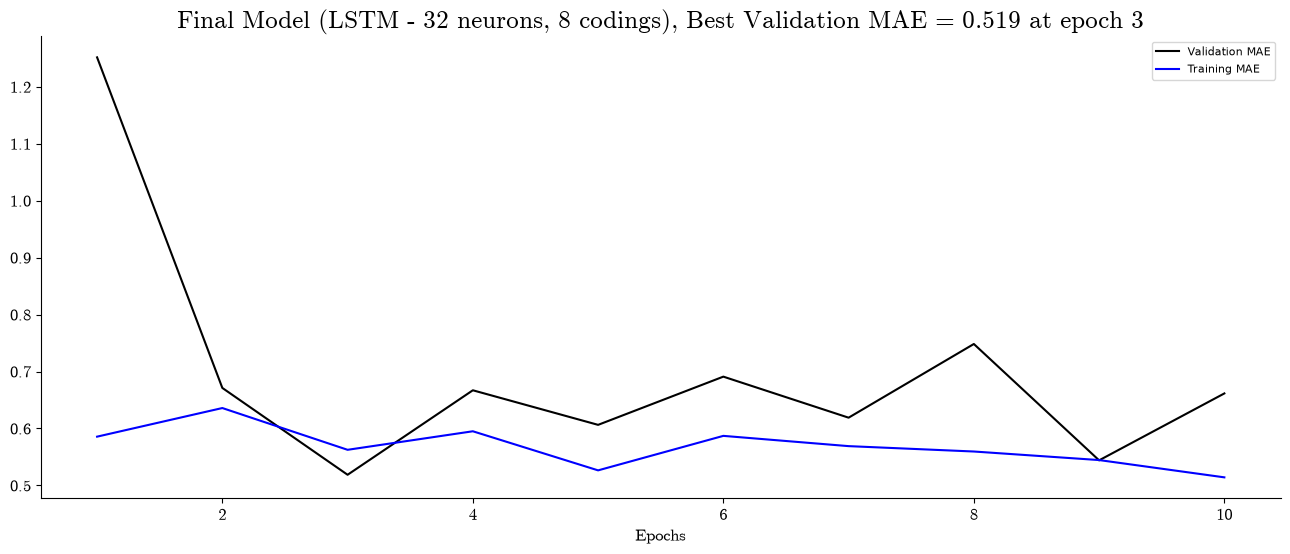

In [48]:
# Plot 3 - Recurrent Autoencoder, Training vs. Validation Accuracy
plt.clf()
plt.figure(figsize=(16,6))
plt.plot(range(1,11), best_val_MAE, 'b', label = "Validation MAE", color="black")
plt.plot(range(1,11), best_train_MAE, 'b',label = "Training MAE",color="blue")
plt.title('Final Model (LSTM - 32 neurons, 8 codings), Best Validation MAE = 0.519 at epoch 3', font=fpath, fontsize=18)
plt.yticks(font=fpath, fontsize=12)
plt.xticks(font=fpath, fontsize=12)
plt.xlabel("Epochs",font=fpath, fontsize=12)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.legend(loc = 'upper right', fontsize=8)
plt.savefig("final_model.png", dpi=600, bbox_inches="tight")
plt.show()

# **Recurrent Autoencoder Comparison**

## Configure input data to 2D tensors

In [250]:
# Additional padding to ensure input/output dimensions align after Convolutions and Pooling
max_set_dim_with_pad = max_set_dim + 56

In [18]:
# Function which converts Dataframe to 2D tensors with dimension (max_set_dim_with_pad, 21) 
def to_padded_2D(df, max_set_dim_with_pad=max_set_dim_with_pad):
    
    feature_columns = df.columns[~df.columns.isin(["row","set"])]
    sets = df["set"].unique()
    random.shuffle(sets) # Turn off random shuffling after autoencoder is trained
    input_sets = []
    
    # Create 2D padded matrix for each set in Dataframe 
    for s in sets:
        
        # Filter to corresponding week
        one_set = df[df["set"] == s]
        nrows = one_set.shape[0]
        
        # Pad 2D array to have max_set_dim_with_pad rows
        one_set = np.pad(one_set[feature_columns], [[0,max_set_dim_with_pad-nrows], [0,0]])
        
        # Convert to tensor
        one_set = tf.constant(one_set)
        
        yield one_set

traffic_train_ae_tensors = tf.data.Dataset.from_generator(lambda: to_padded_2D(traffic_train_prep), output_signature=tf.TensorSpec(shape=(max_set_dim_with_pad,21)))
traffic_train_ae_tensors = traffic_train_ae_tensors.batch(10).map(lambda x: (x,x))
traffic_val_ae_tensors = tf.data.Dataset.from_generator(lambda: to_padded_2D(traffic_val_prep), output_signature=tf.TensorSpec(shape=(max_set_dim_with_pad,21)))
traffic_val_ae_tensors = traffic_val_ae_tensors.batch(10).map(lambda x: (x,x))

In [12]:
traffic_train_ae_tensors.element_spec

(TensorSpec(shape=(None, 19840, 21), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 19840, 21), dtype=tf.float32, name=None))

## Architecture

In [13]:
# Feed each traffic hour (represented by a max_set_dim_with_pad x 21 matrix)
n_codings=8 # Best Deep Sets model coding-size

rn_encoder = models.Sequential([
    layers.Conv1D(21, kernel_size=5, padding="same", activation="selu", input_shape = (max_set_dim_with_pad,21)), # Output size: 19784x21
    layers.MaxPool1D(pool_size=8), # Reduce sequence length before inputting into recurrent layer
    layers.Conv1D(21, kernel_size=5, padding="same", activation="selu"), 
    layers.MaxPool1D(pool_size=8), # Reduce sequence length before inputting into recurrent layer
    layers.LSTM(16, return_sequences=True), 
    layers.LSTM(n_codings)
])

rn_decoder = models.Sequential([
    layers.RepeatVector(max_set_dim_with_pad, input_shape=[n_codings]),
    layers.Conv1D(n_codings, kernel_size=5, padding="same", activation="selu", input_shape = (max_set_dim_with_pad, n_codings)), # Again, need to reduce sequence length
    layers.MaxPool1D(pool_size=8), # Reduce sequence length before inputting into recurrent layer
    layers.Conv1D(21, kernel_size=5, padding="same", activation="selu"), 
    layers.MaxPool1D(pool_size=8), # Reduce sequence length before inputting into recurrent layer
    layers.LSTM(16, return_sequences=True),
    layers.TimeDistributed(layers.Dense(21)),
    layers.Conv1DTranspose(21, kernel_size=5, strides=8, padding="valid"),
    layers.Conv1DTranspose(21, kernel_size=5, strides=8, padding="same")
])

rn_ae = models.Sequential([rn_encoder, rn_decoder])
rn_encoder.summary()

/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/reshaping/repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19840, 21)      │         2,226 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2480, 21)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2480, 21)       │         2,226 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 310, 21)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 310, 16)        │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,684 (30.02 KB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [ ]:
# Train recurrent autoencoder to minimize reconstruction loss
rn_ae.compile(loss="mse", optimizer="adam")
history_rn_ae = rn_ae.fit(traffic_train_ae_tensors, epochs=10)

## Train RNN on Traffic-Hour Codings

In [19]:
# Compute embeddings for train and validation set
ae_embeddings_train = rn_encoder.predict(traffic_train_ae_tensors)
ae_embeddings_val = rn_encoder.predict(traffic_val_ae_tensors)

4284/4284 ━━━━━━━━━━━━━━━━━━━━ 551s 129ms/step


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


656/656 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step


In [21]:
def ae_tensors(list):
    
    weeks = int(len(list) / 168)
    
    for w in range(weeks):
        
        start = 168*w
        end = start + 168
        week_ae_tensor = tf.constant(list[start:end]) # Convert list of 168 8x1 vectors into a 2D tensor

        yield week_ae_tensor
        

# Configure to tensors for RNN
traffic_train_ae_tensors = tf.data.Dataset.from_generator(lambda: ae_tensors(ae_embeddings_train), output_signature=tf.TensorSpec(shape=(168,8)))
gas_train_tensors = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(gas_train_prep))
train_ae_tensors = tf.data.Dataset.zip((traffic_train_ae_tensors,gas_train_tensors))
train_ae_tensors = train_ae_tensors.batch(4).shuffle(buffer_size=255).prefetch(tf.data.AUTOTUNE) 

traffic_val_ae_tensors = tf.data.Dataset.from_generator(lambda: ae_tensors(ae_embeddings_val), output_signature=tf.TensorSpec(shape=(168,8)))
gas_val_tensors = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(gas_val_prep))
val_ae_tensors = tf.data.Dataset.zip((traffic_val_ae_tensors,gas_val_tensors))
val_ae_tensors = val_ae_tensors.batch(4).shuffle(buffer_size=39).prefetch(tf.data.AUTOTUNE) 

In [26]:
# Feed these codings into the deep sets RNN
# Set Pooling - sum traffic event embeddings by set
rn_ae_model = models.Sequential()
rn_ae_model.add(layers.Conv1D(8, 5, padding="same", input_shape=(168, n_codings)))
rn_ae_model.add(layers.BatchNormalization())
rn_ae_model.add(layers.LSTM(32, activation="relu"))
rn_ae_model.add(layers.Dense(1, activation="linear"))

# Train recurrent network
rn_ae_model.compile(loss="mean_squared_error", metrics = ["mean_absolute_error"], optimizer="adam")
history_rn_ae_model = rn_ae_model.fit(train_ae_tensors, epochs=30, validation_data=val_ae_tensors)

Epoch 1/30


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


     64/Unknown 3s 23ms/step - loss: 1.0081 - mean_absolute_error: 0.6744

/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 1.0081 - mean_absolute_error: 0.6744 - val_loss: 0.8044 - val_mean_absolute_error: 0.6823
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.9992 - mean_absolute_error: 0.6680 - val_loss: 0.8018 - val_mean_absolute_error: 0.6822
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.0087 - mean_absolute_error: 0.6768 - val_loss: 0.7987 - val_mean_absolute_error: 0.6820
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 1.0015 - mean_absolute_error: 0.6621 - val_loss: 0.8031 - val_mean_absolute_error: 0.6823
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.9989 - mean_absolute_error: 0.6651 - val_loss: 0.8030 - val_mean_absolute_error: 0.6823
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.0026 - mean_absolute_error: 0.6657 - val_loss: 0.7999 - val_mean_absolute_error: 0.6821
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.0058 - mean_absolute_error: 0.6700 - val_loss: 0.8150 - 

/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/3944077769.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(range(30), history_rn_ae_model.history["val_mean_absolute_error"], 'b', label = "Validation MAE", color="black")
/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/3944077769.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(range(30), history_rn_ae_model.history["mean_absolute_error"], 'b',label = "Training MAE",color="blue")


<Figure size 640x480 with 0 Axes>

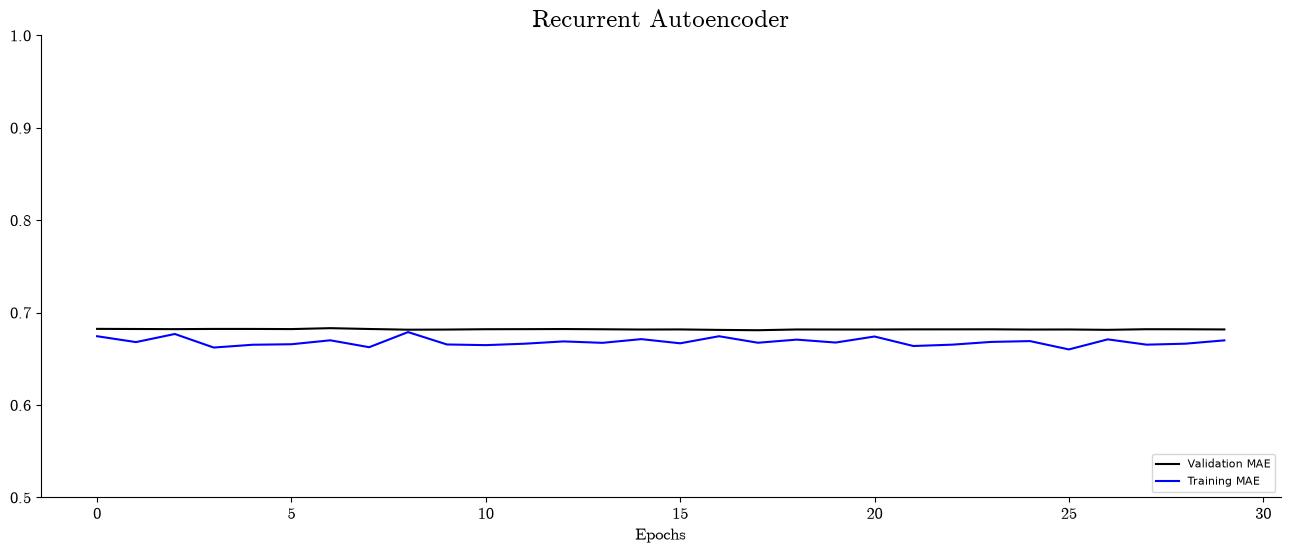

In [49]:
# Plot 4 - Recurrent Autoencoder, Training vs. Validation Accuracy
plt.clf()
plt.figure(figsize=(16,6))
plt.plot(range(30), history_rn_ae_model.history["val_mean_absolute_error"], 'b', label = "Validation MAE", color="black")
plt.plot(range(30), history_rn_ae_model.history["mean_absolute_error"], 'b',label = "Training MAE",color="blue")
plt.title('Recurrent Autoencoder', font=fpath, fontsize=18)
plt.yticks(font=fpath, fontsize=12)
plt.ylim(0.5,1)
plt.xticks(font=fpath, fontsize=12)
plt.xlabel("Epochs",font=fpath, fontsize=12)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.legend(loc = 'lower right', fontsize=8)
plt.savefig("recurrent_autoencoder.png", dpi=600, bbox_inches="tight")
plt.show()

# **Final Model Performance**

In [66]:
# Train best model on entire training set (train + validation) over 3 epochs
total_traffic_train_prep = pd.concat([traffic_train_prep,traffic_val_prep])
total_gas_train_prep = pd.concat([gas_train_prep,gas_val_prep])

total_traffic_train_tensors = tf.data.Dataset.from_generator(lambda: to_tensor(total_traffic_train_prep), output_signature=tf.TensorSpec(shape=(168,max_set_dim,21)))
total_gas_train_tensors = tf.data.Dataset.from_tensor_slices(tf.convert_to_tensor(total_gas_train_prep))
total_train_tensors = tf.data.Dataset.zip((total_traffic_train_tensors,total_gas_train_tensors))
total_train_tensors = total_train_tensors.batch(4).shuffle(buffer_size=10).prefetch(tf.data.AUTOTUNE) # prefetch to allow later elements to be prepared while current are processed


In [ ]:
final_predictions = finalmodel.predict(test_tensors)

I0000 00:00:1785981052.667174 7524994 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785981062.681237 7524994 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 3 of 10
I0000 00:00:1785981085.170256 7524994 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785981100.992391 7524994 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785981111.782850 7524994 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785981117.010087 7524994 shuffle_dataset_op.cc:483] Shuffle buffer filled.


12/12 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


array([[-4.18085344e-02],
       [-8.38141069e-02],
       [-6.04931749e-02],
       [-1.02081627e-01],
       [-1.05360106e-01],
       [-1.33889884e-01],
       [-4.17666398e-02],
       [-6.28266186e-02],
       [ 3.87433283e-02],
       [ 8.11090469e-02],
       [ 3.71794142e-02],
       [ 1.36509880e-01],
       [-1.03100985e-01],
       [-5.66545153e+00],
       [-6.83452412e-02],
       [ 1.92977294e-01],
       [-1.03080638e-01],
       [-1.03292614e-01],
       [-8.49844366e-02],
       [ 1.01460936e-02],
       [-1.08521909e-01],
       [-1.22515529e-01],
       [-1.04621328e-01],
       [-9.29351300e-02],
       [-6.14843555e-02],
       [-5.02382107e-02],
       [-2.84215845e-02],
       [-5.19087445e-03],
       [-7.49470666e-02],
       [-8.96007866e-02],
       [-7.34275132e-02],
       [-4.46807444e-02],
       [-8.18187892e-02],
       [-6.11926839e-02],
       [-1.76883005e-02],
       [-8.11990723e-02],
       [ 5.04099298e-03],
       [-5.78698050e-03],
       [-5.1

In [71]:
finalmodel = set_pooling(memory_cell="lstm", n_codings=8)
finalmodel.compile(loss="mean_squared_error", metrics=['mean_absolute_error'], optimizer='adam')
historyfinalmodel = finalmodel.fit(total_train_tensors, 
                                   epochs=3, verbose=1,
                                   validation_data=test_tensors)

Epoch 1/3


/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adap

     74/Unknown 648s 8s/step - loss: 1.0136 - mean_absolute_error: 0.6401

/Users/olearyl/Library/Python/3.12/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
I0000 00:00:1785979440.549900 7493985 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785979458.827834 7493985 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 4 of 10
I0000 00:00:1785979472.394527 7493985 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785979488.161146 7493985 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785979498.792685 7493985 shuffle_da

74/74 ━━━━━━━━━━━━━━━━━━━━ 743s 10s/step - loss: 1.0136 - mean_absolute_error: 0.6401 - val_loss: 2644.3572 - val_mean_absolute_error: 38.3930
Epoch 2/3


...

74/74 ━━━━━━━━━━━━━━━━━━━━ 740s 10s/step - loss: 1.0245 - mean_absolute_error: 0.6966 - val_loss: 1.4714 - val_mean_absolute_error: 0.7950
Epoch 3/3


I0000 00:00:1785980271.674860 7510547 shuffle_dataset_op.cc:453] ShuffleDatasetV3:184: Filling up shuffle buffer (this may take a while): 6 of 10
I0000 00:00:1785980282.663476 7510547 shuffle_dataset_op.cc:453] ShuffleDatasetV3:184: Filling up shuffle buffer (this may take a while): 8 of 10
I0000 00:00:1785980293.902230 7510547 shuffle_dataset_op.cc:483] Shuffle buffer filled.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 1.0617 - mean_absolute_error: 0.7190

I0000 00:00:1785980919.927340 7522240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 2 of 10
I0000 00:00:1785980938.479107 7522240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 4 of 10
I0000 00:00:1785980951.958571 7522240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 5 of 10
I0000 00:00:1785980967.570079 7522240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 7 of 10
I0000 00:00:1785980978.292886 7522240 shuffle_dataset_op.cc:453] ShuffleDatasetV3:173: Filling up shuffle buffer (this may take a while): 9 of 10
I0000 00:00:1785980983.486577 7522240 shuffle_dataset_op.cc:483] Shuffle buffer filled.


74/74 ━━━━━━━━━━━━━━━━━━━━ 740s 10s/step - loss: 1.0617 - mean_absolute_error: 0.7190 - val_loss: 1.0318 - val_mean_absolute_error: 0.5981


In [ ]:
# Plot 5 - Recurrent Autoencoder, Training vs. Validation Accuracy
plt.clf()
plt.figure(figsize=(16,6))
plt.plot(history_rn_ae_model.history["val_mean_absolute_error"], 'b', label = "Validation MAE", color="black")
plt.plot(range(30), history_rn_ae_model.history["mean_absolute_error"], 'b',label = "Training MAE",color="blue")
plt.title('Recurrent Autoencoder', font=fpath, fontsize=18)
plt.yticks(font=fpath, fontsize=12)
plt.ylim(0.5,1)
plt.xticks(font=fpath, fontsize=12)
plt.xlabel("Epochs",font=fpath, fontsize=12)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.legend(loc = 'lower right', fontsize=8)
plt.savefig("recurrent_autoencoder.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
final_preds_raw = (final_predictions * train_std_gas) + train_mean_gas
final_preds_raw = final_preds_raw.ravel()

pd.DataFrame({"Date": gas_df_test["date"],
              "Prediction": final_preds_raw,
              "Observed": gas_df_test["weekly_gas"] })


,Date,Prediction,Observed
294,2021-10-08,9050.159389,9186
295,2021-10-15,9018.570604,9634
296,2021-10-22,9036.108275,9323
297,2021-10-29,9004.833169,9504
298,2021-11-05,9002.367707,9259
299,2021-11-12,8980.912909,9241
300,2021-11-19,9050.190895,9334
301,2021-11-26,9034.353492,8796
302,2021-12-03,9110.735532,8963
303,2021-12-10,9142.595153,9472


/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/2267407370.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(gas_df_test["date"], final_preds_raw, 'b', label = "Predicted", color="black")
/var/folders/h6/d77gprcd4250j91zv0j5bpth0000gp/T/ipykernel_97424/2267407370.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(gas_df_test["date"], gas_df_test["weekly_gas"], 'b', label = "Observed", color="red")


<Figure size 640x480 with 0 Axes>

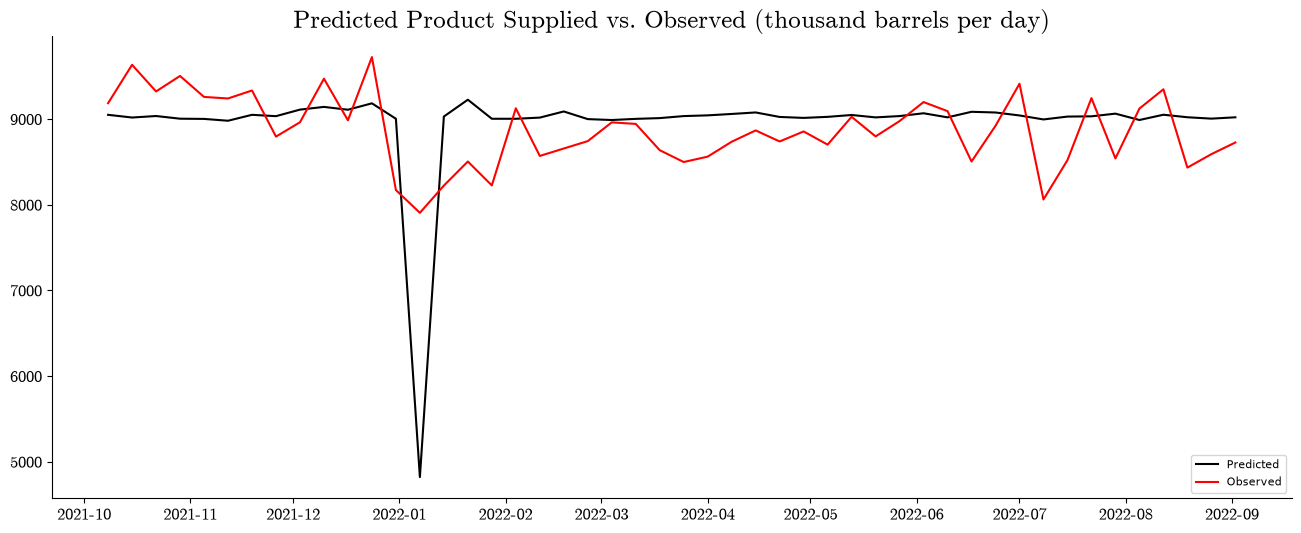

In [116]:
# Plot 5 - Recurrent Autoencoder, Training vs. Validation Accuracy
plt.clf()
plt.figure(figsize=(16,6))
plt.plot(gas_df_test["date"], final_preds_raw, 'b', label = "Predicted", color="black")
plt.plot(gas_df_test["date"], gas_df_test["weekly_gas"], 'b', label = "Observed", color="red")
plt.title('Predicted Product Supplied vs. Observed (thousand barrels per day)', font=fpath, fontsize=18)
plt.xticks(font=fpath, fontsize=12)
plt.yticks(font=fpath, fontsize=12)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.legend(loc = 'lower right', fontsize=8)
plt.savefig("recurrent_autoencoder.png", dpi=600, bbox_inches="tight")
plt.show()